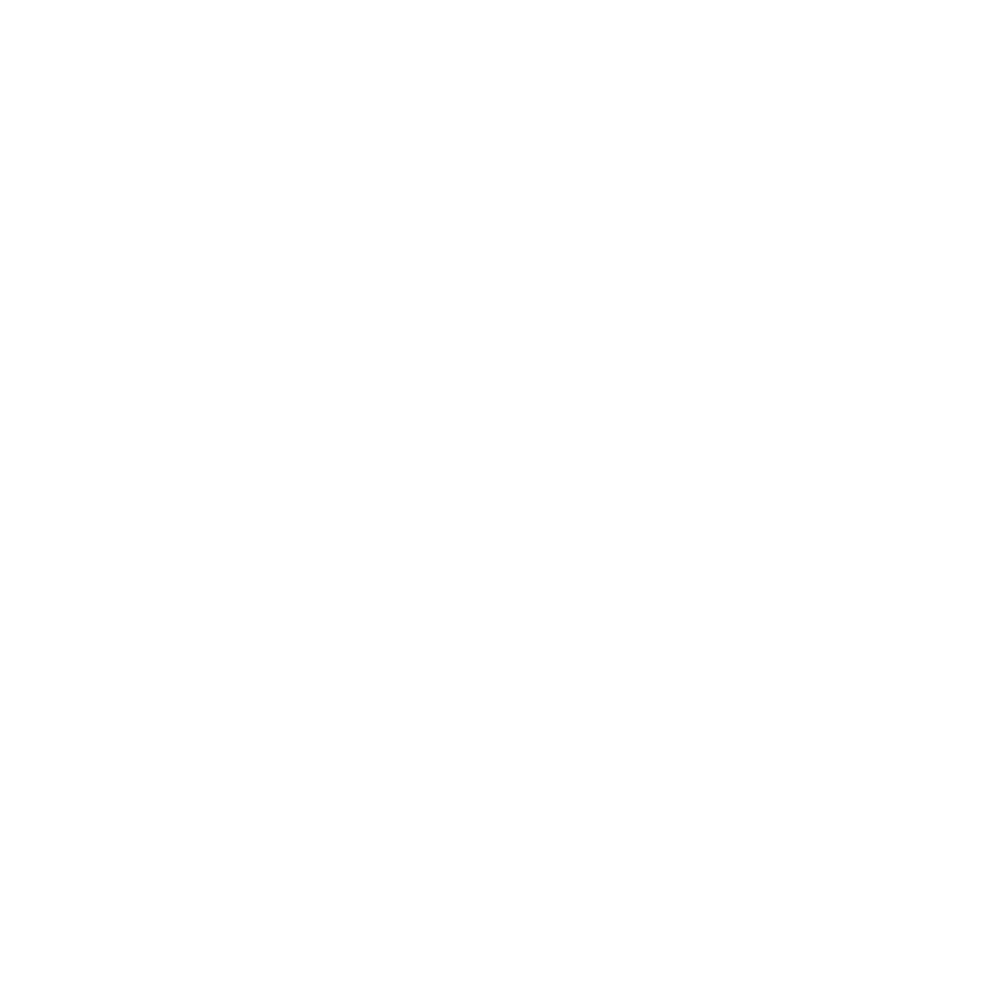

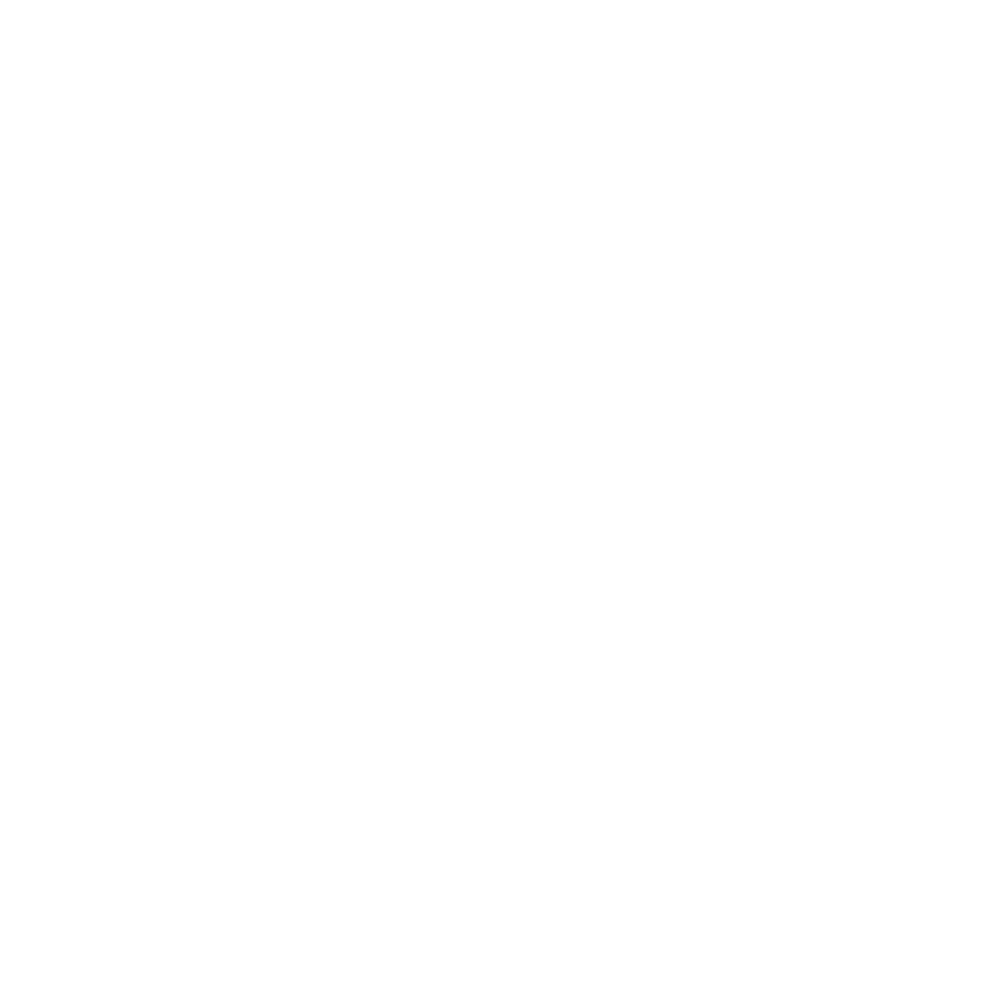

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import (
    FloatSlider,
    VBox,
    HBox,
    Button,
    Output
)

from IPython.display import display


# ----------------------------------------------------
# Time axis
# ----------------------------------------------------

t = np.linspace(0, 1, 2000)

rng = np.random.default_rng()


# ----------------------------------------------------
# Initial random parameters
# ----------------------------------------------------

A0 = rng.uniform(0.5, 2.0, 3)
f0 = rng.uniform(1, 10, 3)
phi0 = rng.uniform(0, 2*np.pi, 3)


# ----------------------------------------------------
# Create sliders
# ----------------------------------------------------

sliders = []

for k in range(3):

    A = FloatSlider(
        value=float(A0[k]),
        min=0,
        max=3,
        step=0.05,
        description=f"A{k+1}",
        continuous_update=True
    )

    f = FloatSlider(
        value=float(f0[k]),
        min=0.5,
        max=20,
        step=0.1,
        description=f"f{k+1}",
        continuous_update=True
    )

    phi = FloatSlider(
        value=float(phi0[k]),
        min=0,
        max=2*np.pi,
        step=0.05,
        description=f"φ{k+1}",
        continuous_update=True
    )

    sliders.append([A, f, phi])


# ----------------------------------------------------
# Plot function
# ----------------------------------------------------

output = Output()


def update_plot(*args):

    with output:

        output.clear_output(wait=True)

        signals = []

        for group in sliders:

            A = group[0].value
            f = group[1].value
            phi = group[2].value

            x = A*np.sin(
                2*np.pi*f*t + phi
            )

            signals.append(x)


        total = np.sum(signals, axis=0)


        fig, axes = plt.subplots(
            4,
            1,
            figsize=(10,10),
            sharex=True
        )


        for k in range(3):

            axes[k].plot(
                t,
                signals[k]
            )

            axes[k].set_ylabel(
                rf"$x_{k+1}(t)$"
            )

            axes[k].grid(True)


        # Sum signal

        axes[3].plot(
            t,
            total,
            color="red",
            linewidth=2
        )

        axes[3].set_ylabel(
            "$x(t)=x_1+x_2+x_3$"
        )

        axes[3].set_xlabel(
            "Time"
        )

        axes[3].grid(True)


        plt.tight_layout()
        plt.show()



# ----------------------------------------------------
# Connect sliders
# ----------------------------------------------------

for group in sliders:

    for slider in group:

        slider.observe(
            update_plot,
            names="value"
        )


# ----------------------------------------------------
# Randomize button
# ----------------------------------------------------

button = Button(
    description="Randomize",
    button_style="info"
)


def randomize(change):

    for k in range(3):

        sliders[k][0].value = rng.uniform(0.5,2.0)
        sliders[k][1].value = rng.uniform(1,10)
        sliders[k][2].value = rng.uniform(0,2*np.pi)


button.on_click(randomize)


# ----------------------------------------------------
# Display
# ----------------------------------------------------

controls = []

for group in sliders:

    controls.append(
        HBox(
            [
                group[0],
                group[1],
                group[2]
            ]
        )
    )


display(
    VBox(
        controls +
        [
            button,
            output
        ]
    )
)


update_plot()